# Importancia de las variables

In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import pandas as pd
import os

import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv(os.path.join(os.getcwd(), "../data/rendimiento_estudiantes_train_EDA.csv"), index_col=0)

X1 = df.drop(columns=["T3"]).values
X2 = df.drop(columns=["T1","T2","T3", "T1_T2_interaction"]).values
y = df["T3"].values

### Modelo no supervisado

In [80]:
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X2, y)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='r2')

         Variable  Importancia
5       suspensos     0.207219
18         faltas     0.130586
34   asignatura_M     0.049328
0            edad     0.044923
16          SalAm     0.039608
15      TiempoLib     0.038558
4   TiempoEstudio     0.036211
2            Pedu     0.035418
1            Medu     0.031402
6           apoyo     0.031334


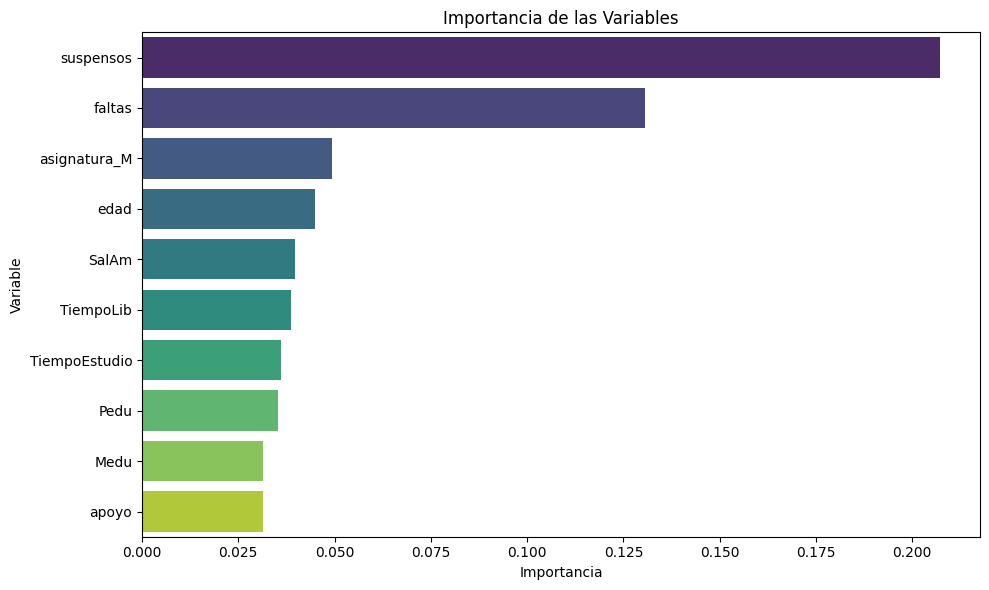

In [81]:
rf_model = grid_rf.best_estimator_

importances = rf_model.feature_importances_
# Ensure feature_names corresponds to the columns used in X2
feature_names = df.drop(columns=["T1", "T2", "T3", "T1_T2_interaction"]).columns

# Creamos un DataFrame para visualizar las importancias
importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
importance_df = importance_df.sort_values(by='Importancia', ascending=False)

# Mostramos las 10 variables más importantes
print(importance_df.head(10))

# Graficamos la importancia de las variables
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Importancia de las Variables')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

           Variable  Importancia
22        servicios     0.010720
27       TamFam_>=4     0.010654
9            extras     0.010399
10       enfermeria     0.009068
13           pareja     0.008891
12         internet     0.008291
30      razon_otros     0.008133
29  razon_optativas     0.006203
28      EstPadres_S     0.006141
21          sanidad     0.005829


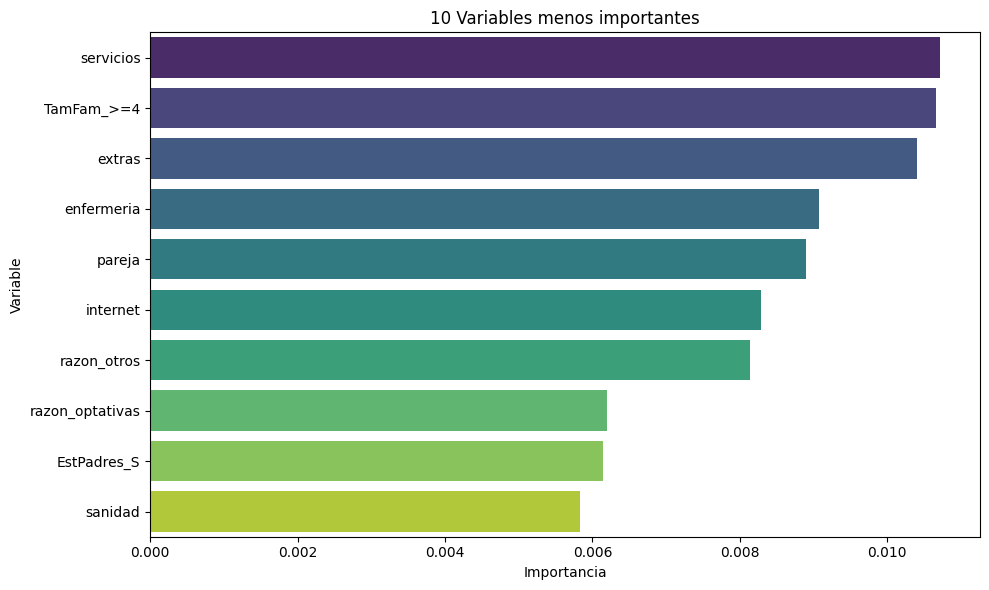

In [82]:
# Mostramos las 10 variables menos importantes
print(importance_df.tail(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.tail(10), x='Importancia', y='Variable', palette='viridis')
plt.title('10 Variables menos importantes')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [83]:
rf_model = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X1, y)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='r2')

Empty DataFrame
Columns: [Variable, Importancia]
Index: []


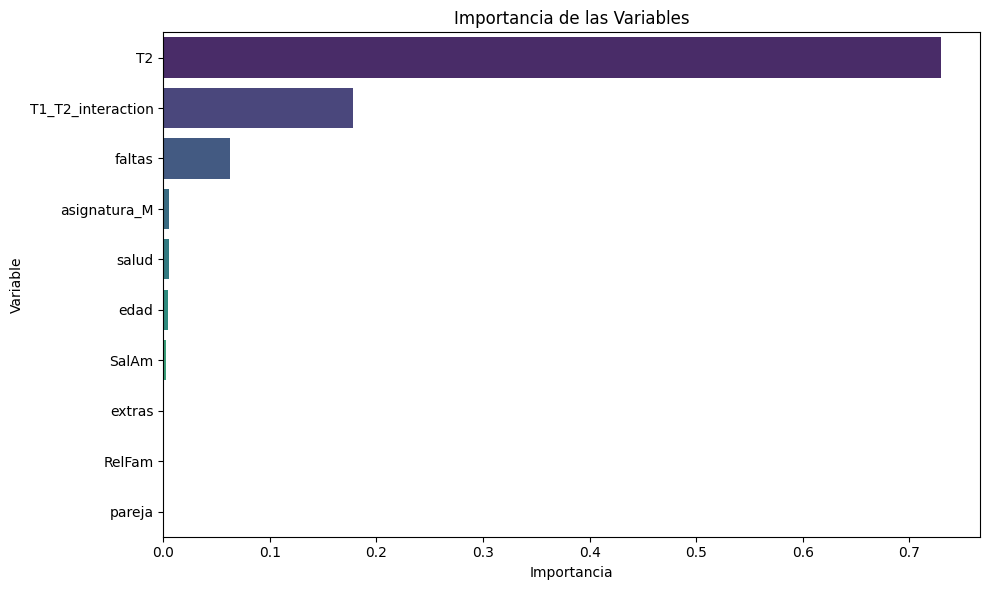

In [84]:
rf_model = grid_rf.best_estimator_

importances = rf_model.feature_importances_
# Ensure feature_names corresponds to the columns used in X1
feature_names = df.drop(columns=["T3"]).columns

# Creamos un DataFrame para visualizar las importancias
importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
importance_df = importance_df.sort_values(by='Importancia', ascending=False)

# Mostramos las 10 variables más importantes
#print(importance_df.head(10))

mtrab_ptrab_importance = importance_df[importance_df['Variable'].str.contains('Mtrab|Ptrab')]

# Mostrar las importancias de estas columnas
print(mtrab_ptrab_importance)


# Graficamos la importancia de las variables
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Importancia de las Variables')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### PCA

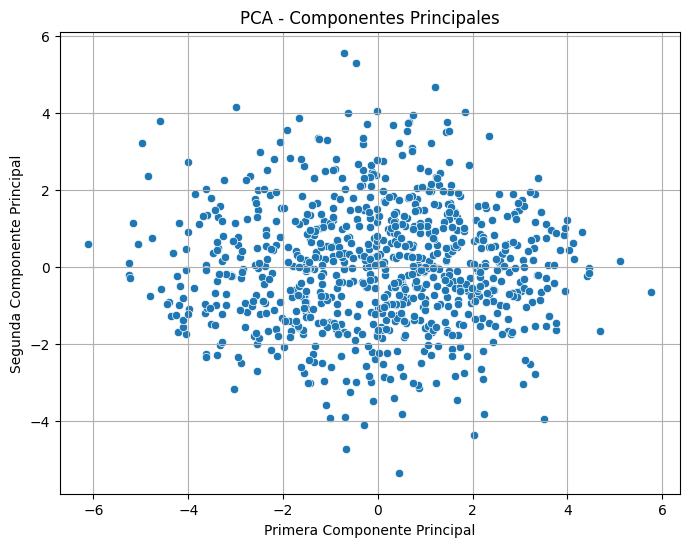

In [85]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=["T3"]))

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convertir a DataFrame para graficar
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Visualización
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title('PCA - Componentes Principales')
plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.grid(True)
plt.show()


In [86]:
# Obtener la matriz de "loadings"
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df.drop(columns=["T3"]).columns
)

# Mostrar los pesos
print(loadings)

abs_loadings = loadings.abs()

                        PC1       PC2
edad              -0.162548 -0.010691
Medu               0.269052  0.275239
Pedu               0.235763  0.249467
TiempoViaje       -0.152846 -0.164164
TiempoEstudio      0.165579 -0.020048
suspensos         -0.254676  0.138433
apoyo             -0.005764  0.105725
ApFam              0.085563  0.203312
academia           0.050608  0.289047
extras             0.072354  0.123929
enfermeria         0.093028  0.021060
EstSup             0.223607  0.015409
internet           0.134139  0.228908
pareja            -0.065059  0.024802
RelFam             0.015303  0.000965
TiempoLib         -0.076511  0.108069
SalAm             -0.072577  0.122340
salud             -0.036633  0.067977
faltas            -0.041844  0.211082
T1                 0.377182 -0.263322
T2                 0.372178 -0.265884
docencia           0.178512  0.173188
otros             -0.131742 -0.177524
sanidad            0.134362  0.121649
servicios          0.046548  0.106297
Alc_comb    

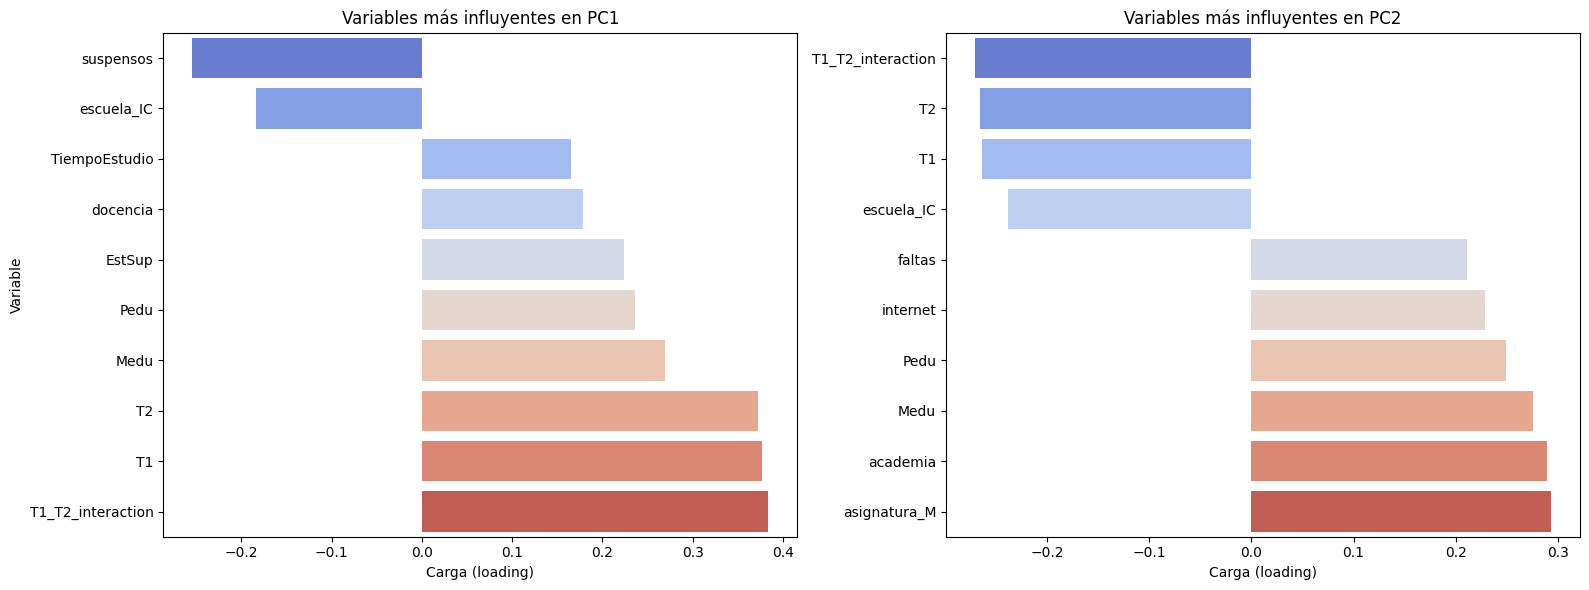

In [87]:

# Seleccionamos las 10 variables con mayor valor absoluto en cada componente
top_pc1 = abs_loadings['PC1'].nlargest(10).index
top_pc2 = abs_loadings['PC2'].nlargest(10).index

# Extraer los valores originales (no absolutos) para esas variables
top_pc1_values = loadings.loc[top_pc1, 'PC1'].sort_values()
top_pc2_values = loadings.loc[top_pc2, 'PC2'].sort_values()

# Graficar los resultados
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

sns.barplot(x=top_pc1_values.values, y=top_pc1_values.index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Variables más influyentes en PC1')
axes[0].set_xlabel('Carga (loading)')
axes[0].set_ylabel('Variable')

sns.barplot(x=top_pc2_values.values, y=top_pc2_values.index, ax=axes[1], palette='coolwarm')
axes[1].set_title('Variables más influyentes en PC2')
axes[1].set_xlabel('Carga (loading)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=["T1","T2","T3", "T1_T2_interaction"]))

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convertir a DataFrame para graficar
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Obtener la matriz de "loadings"
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df.drop(columns=["T1","T2","T3", "T1_T2_interaction"]).columns
)

# Mostrar los pesos
print(loadings)


                       PC1       PC2
edad             -0.208226  0.243618
Medu              0.377045  0.151686
Pedu              0.334636  0.135464
TiempoViaje      -0.222611 -0.044192
TiempoEstudio     0.167448 -0.160842
suspensos        -0.214029  0.262380
apoyo             0.069568 -0.109051
ApFam             0.181465  0.024553
academia          0.164770  0.154719
extras            0.117119  0.124017
enfermeria        0.120138 -0.080120
EstSup            0.247129 -0.171664
internet          0.212118  0.200107
pareja           -0.067088  0.106041
RelFam            0.009513  0.047107
TiempoLib        -0.071731  0.319875
SalAm            -0.052199  0.298874
salud            -0.013127  0.098655
faltas            0.015387  0.277105
docencia          0.249573  0.099351
otros            -0.200935 -0.116634
sanidad           0.198226 -0.024494
servicios         0.081722  0.105267
Alc_comb         -0.087116  0.374441
escuela_IC       -0.274192 -0.092808
sexo_M           -0.005719  0.282273
e

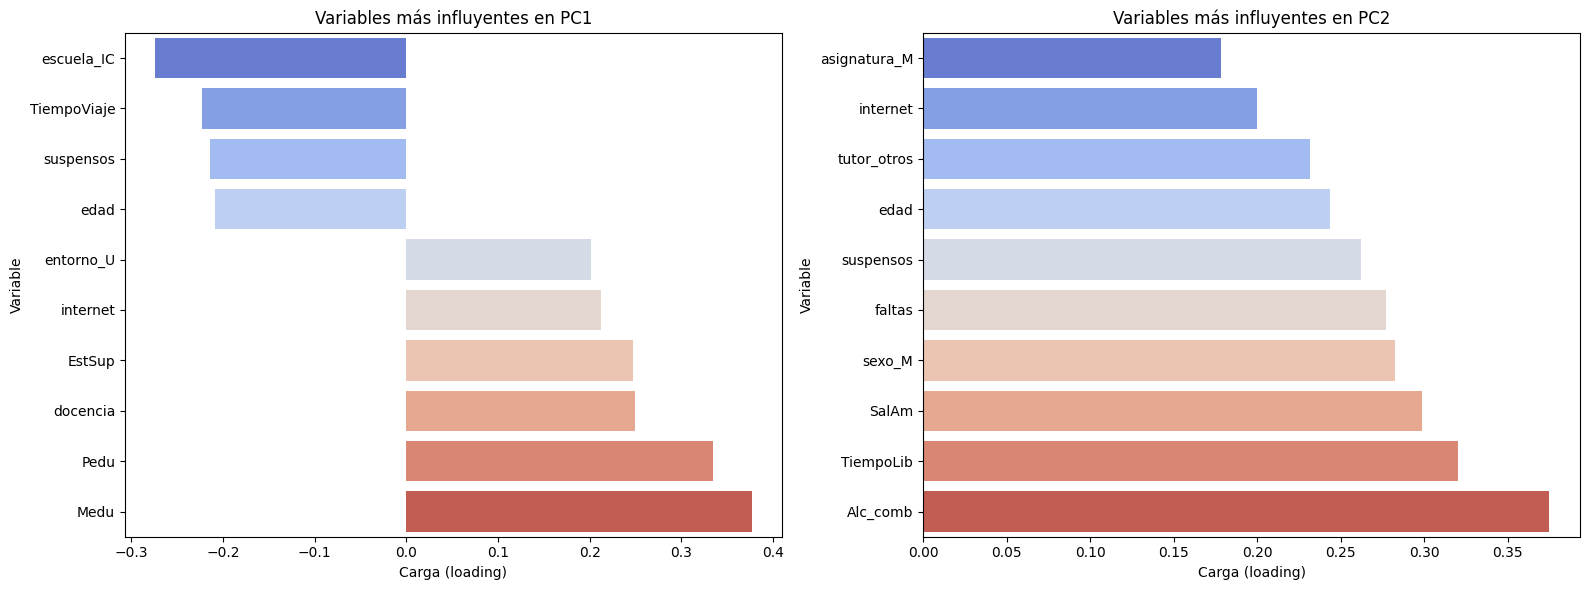

In [89]:
abs_loadings = loadings.abs()

# Seleccionamos las 10 variables con mayor valor absoluto en cada componente
top_pc1 = abs_loadings['PC1'].nlargest(10).index
top_pc2 = abs_loadings['PC2'].nlargest(10).index

# Extraer los valores originales (no absolutos) para esas variables
top_pc1_values = loadings.loc[top_pc1, 'PC1'].sort_values()
top_pc2_values = loadings.loc[top_pc2, 'PC2'].sort_values()

# Graficar los resultados
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

sns.barplot(x=top_pc1_values.values, y=top_pc1_values.index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Variables más influyentes en PC1')
axes[0].set_xlabel('Carga (loading)')
axes[0].set_ylabel('Variable')

sns.barplot(x=top_pc2_values.values, y=top_pc2_values.index, ax=axes[1], palette='coolwarm')
axes[1].set_title('Variables más influyentes en PC2')
axes[1].set_xlabel('Carga (loading)')
axes[1].set_ylabel('Variable')  # Añadimos etiqueta para el eje Y del segundo subplot
plt.tight_layout()
plt.show()


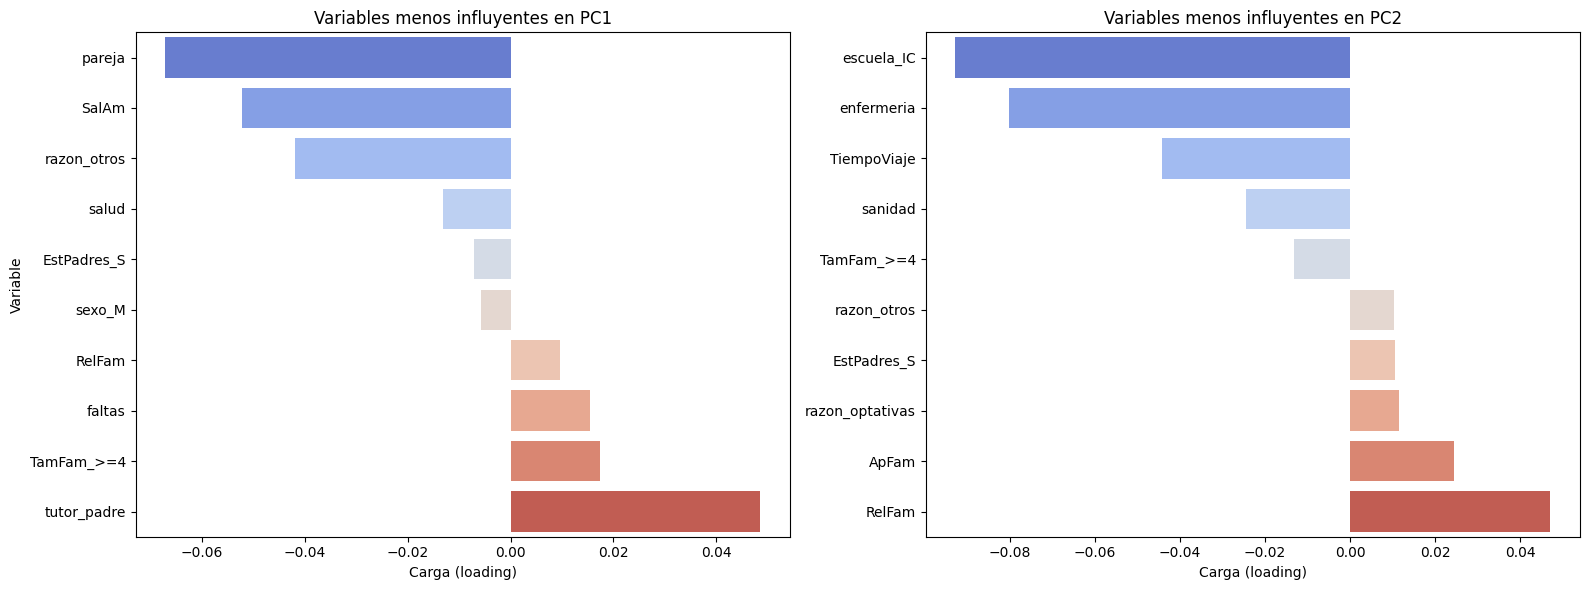

In [90]:
# Seleccionamos las 10 variables con menor valor absoluto en cada componente
bottom_pc1 = abs_loadings['PC1'].nsmallest(10).index
bottom_pc2 = abs_loadings['PC2'].nsmallest(10).index

# Extraer los valores originales (no absolutos) para esas variables
bottom_pc1_values = loadings.loc[bottom_pc1, 'PC1'].sort_values()
bottom_pc2_values = loadings.loc[bottom_pc2, 'PC2'].sort_values()

# Graficar los resultados
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

sns.barplot(x=bottom_pc1_values.values, y=bottom_pc1_values.index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Variables menos influyentes en PC1')
axes[0].set_xlabel('Carga (loading)')
axes[0].set_ylabel('Variable')

sns.barplot(x=bottom_pc2_values.values, y=bottom_pc2_values.index, ax=axes[1], palette='coolwarm')
axes[1].set_title('Variables menos influyentes en PC2')
axes[1].set_xlabel('Carga (loading)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Kmeans Clustering

c:\Users\gonza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\gonza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\gonza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\gonza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

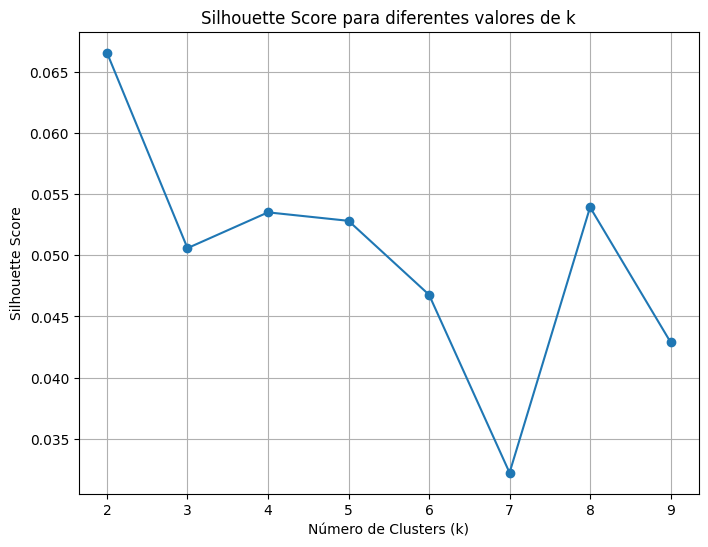

Número óptimo de clusters según el Silhouette Score: 2


c:\Users\gonza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


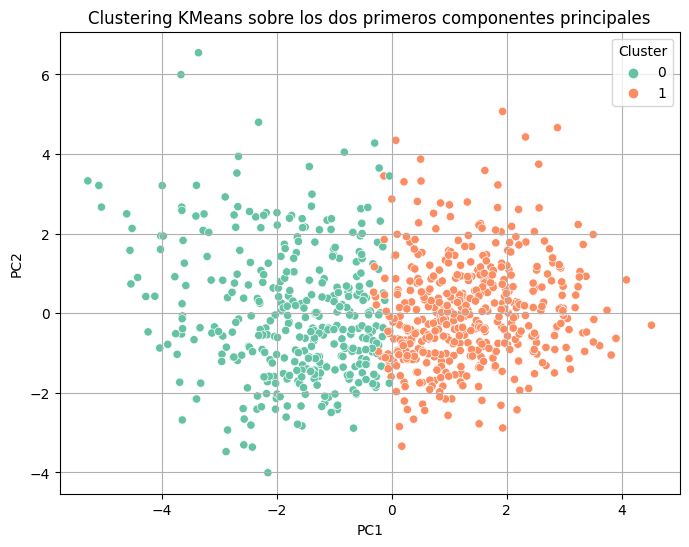

Silhouette Score para k=2: 0.067


In [91]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reutilizamos X_scaled del código anterior

# Elegimos un valor de k óptimo basado en el Silhouette Score
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Visualización del Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(K_range, sil_scores, marker='o')
plt.title('Silhouette Score para diferentes valores de k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Seleccionamos el k con el mayor Silhouette Score
k_optimo = K_range[sil_scores.index(max(sil_scores))]
print(f'Número óptimo de clusters según el Silhouette Score: {k_optimo}')

# Aplicamos KMeans con el número óptimo de clusters
kmeans_final = KMeans(n_clusters=k_optimo, random_state=0)
labels = kmeans_final.fit_predict(X_scaled)

# Visualización del clustering con PCA (PC1 y PC2)
pca_df['Cluster'] = labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.title('Clustering KMeans sobre los dos primeros componentes principales')
plt.grid(True)
plt.show()

# Métrica adicional
sil_score = silhouette_score(X_scaled, labels)
print(f'Silhouette Score para k={k_optimo}: {sil_score:.3f}')